In [2]:
# Ejecutar solo si faltan librerías
%pip install pandas numpy matplotlib seaborn scikit-learn missingno upsetplot openpyxl

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
  Using cached UpSetPlot-0.9.0.tar.gz (23 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - --------------------

# *Volatilidad del oro y comportamiento del sector oro/plata*

## *Análisis dirigido por la pregunta:*
¿Puede la volatilidad del oro, medida por el índice GVZCLS, ayudar a predecir el comportamiento del sector oro/plata, representado por el índice NASDAQXAU, en el corto plazo?

## *Objetivo general*

Aplicar técnicas de ciencia de datos para analizar la relación entre la volatilidad del oro y el comportamiento del sector oro/plata, generando visualizaciones, tratamiento de datos faltantes, análisis de correlación y modelos predictivos de clasificación y regresión.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
from upsetplot import from_indicators, UpSet

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## ¿Qué dataserts se utilizarán?
Se utilizarán dos datasets obtenidos de FRED:

1. `GVZCLS`: CBOE Gold ETF Volatility Index. Representa la volatilidad esperada del oro.
2. `NASDAQXAU`: PHLX Gold/Silver Sector. Representa el comportamiento del sector oro/plata.

La variable `GVZCLS` será usada como una de las variables predictoras principales, mientras que `NASDAQXAU` será la variable de interés.

In [5]:
gvz= pd.read_csv("GVZCLS.csv")
xau= pd.read_csv("NASDAQXAU.csv")

display(gvz.head())
display(xau.head())

,observation_date,GVZCLS
0,2016-06-10,20.52
1,2016-06-13,21.11
2,2016-06-14,20.63
3,2016-06-15,20.68
4,2016-06-16,21.95


,observation_date,NASDAQXAU
0,2016-06-10,90.39
1,2016-06-13,90.58
2,2016-06-14,88.52
3,2016-06-15,92.42
4,2016-06-16,89.86


In [6]:
print("Dimensiones GVZCLS:", gvz.shape)
print("Dimensiones NASDAQXAU:", xau.shape)
print("\nTipos de datos GVZCLS:")
print(gvz.dtypes)
print("\nTipos de datos NASDAQXAU:")
print(xau.dtypes)

Dimensiones GVZCLS: (2609, 2)
Dimensiones NASDAQXAU: (2609, 2)

Tipos de datos GVZCLS:
observation_date        str
GVZCLS              float64
dtype: object

Tipos de datos NASDAQXAU:
observation_date        str
NASDAQXAU           float64
dtype: object


## ¿Cómo se integran ambos datasets?

Ambos datasets tienen una columna de fecha llamada `observation_date`, por lo que se pueden unir usando esa columna.
El resultado será un solo dataset con la fecha, la volatilidad del oro y el índice del sector oro/plata.

In [7]:
gvz["observation_date"]= pd.to_datetime(gvz["observation_date"])
xau["observation_date"]= pd.to_datetime(xau["observation_date"])

df= pd.merge(
    gvz,
    xau,
    on="observation_date",
    how="outer"
)

df= df.sort_values("observation_date").reset_index(drop=True)
df= df.rename(columns={
    "observation_date": "Fecha"
})

display(df.head())
display(df.tail())
print("Dimensiones del dataset unido:", df.shape)

,Fecha,GVZCLS,NASDAQXAU
0,2016-06-10,20.52,90.39
1,2016-06-13,21.11,90.58
2,2016-06-14,20.63,88.52
3,2016-06-15,20.68,92.42
4,2016-06-16,21.95,89.86


,Fecha,GVZCLS,NASDAQXAU
2604,2026-06-04,23.87,363.35
2605,2026-06-05,28.89,331.31
2606,2026-06-08,27.17,330.46
2607,2026-06-09,28.04,326.12
2608,2026-06-10,32.18,311.36


Dimensiones del dataset unido: (2609, 3)


## ¿Qué nuevas variables se pueden crear para mejorar el análisis?

Se crean variables temporales, variables de retorno, variables rezagadas y medias móviles.
También se crea una variable categórica que indica si el índice NASDAQXAU sube al día siguiente.

In [8]:
# Variables temporales
df["Año"]= df["Fecha"].dt.year
df["Mes_num"]= df["Fecha"].dt.month
df["Trimestre"]= df["Fecha"].dt.quarter

meses= {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

dias= {
    0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves",
    4: "Viernes", 5: "Sábado", 6: "Domingo"
}

df["Mes"]= df["Mes_num"].map(meses)
df["Dia_semana"]= df["Fecha"].dt.dayofweek.map(dias)

# Retornos diarios
df["GVZCLS_ret"]= df["GVZCLS"].pct_change(fill_method=None)
df["NASDAQXAU_ret"]= df["NASDAQXAU"].pct_change(fill_method=None)

# Variables rezagadas
df["GVZCLS_lag1"]= df["GVZCLS"].shift(1)
df["NASDAQXAU_lag1"]= df["NASDAQXAU"].shift(1)

# Medias móviles
df["GVZCLS_MA5"]= df["GVZCLS"].rolling(5, min_periods=3).mean()
df["NASDAQXAU_MA5"]= df["NASDAQXAU"].rolling(5, min_periods=3).mean()

df["GVZCLS_MA20"]= df["GVZCLS"].rolling(20, min_periods=10).mean()
df["NASDAQXAU_MA20"]= df["NASDAQXAU"].rolling(20, min_periods=10).mean()

# Volatilidad móvil de retornos
df["GVZCLS_vol_5d"]= df["GVZCLS_ret"].rolling(5, min_periods=3).std()
df["NASDAQXAU_vol_5d"]= df["NASDAQXAU_ret"].rolling(5, min_periods=3).std()

# Categoría de volatilidad del oro
df["Rango_Volatilidad_Oro"]= pd.qcut(
    df["GVZCLS"],
    q=3,
    labels=["Baja", "Media", "Alta"]
)

# Variable continua objetivo para regresión
df["NASDAQXAU_manana"]= df["NASDAQXAU"].shift(-1)

# Variable categórica objetivo para clasificación
valid_direction = df["NASDAQXAU"].notna() & df["NASDAQXAU_manana"].notna()

df["XAU_sube_manana"]= np.nan
df.loc[valid_direction, "XAU_sube_manana"]= (
    df.loc[valid_direction, "NASDAQXAU_manana"] > df.loc[valid_direction, "NASDAQXAU"]
).astype(int)

df["XAU_sube_manana_cat"]= df["XAU_sube_manana"].map({
    0: "Baja o igual",
    1: "Sube"
})

display(df.head())

,Fecha,GVZCLS,NASDAQXAU,Año,Mes_num,Trimestre,Mes,Dia_semana,GVZCLS_ret,NASDAQXAU_ret,...,GVZCLS_MA5,NASDAQXAU_MA5,GVZCLS_MA20,NASDAQXAU_MA20,GVZCLS_vol_5d,NASDAQXAU_vol_5d,Rango_Volatilidad_Oro,NASDAQXAU_manana,XAU_sube_manana,XAU_sube_manana_cat
0,2016-06-10,20.52,90.39,2016,6,2,Junio,Viernes,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Alta,90.58,1.0,Sube
1,2016-06-13,21.11,90.58,2016,6,2,Junio,Lunes,0.028752,0.002102,...,NaN,NaN,NaN,NaN,NaN,NaN,Alta,88.52,0.0,Baja o igual
2,2016-06-14,20.63,88.52,2016,6,2,Junio,Martes,-0.022738,-0.022742,...,20.753333,89.8300,NaN,NaN,NaN,NaN,Alta,92.42,1.0,Sube
3,2016-06-15,20.68,92.42,2016,6,2,Junio,Miércoles,0.002424,0.044058,...,20.735000,90.4775,NaN,NaN,0.025747,0.033763,Alta,89.86,0.0,Baja o igual
4,2016-06-16,21.95,89.86,2016,6,2,Junio,Jueves,0.061412,-0.027700,...,20.978000,90.3540,NaN,NaN,0.036061,0.032789,Alta,90.34,1.0,Sube


## ¿Cuáles son las medidas de tendencia central y dispersión del dataset?

Se calculan medidas estadísticas como media, mediana, desviación estándar, mínimo, máximo y percentiles para las variables numéricas.

In [9]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
Fecha,2609,2021-06-10 09:36:13.246454,2016-06-10 00:00:00,2018-12-11 00:00:00,2021-06-10 00:00:00,2023-12-11 00:00:00,2026-06-10 00:00:00,NaN
GVZCLS,2516.0,16.665596,8.88,12.6675,15.875,18.59,48.98,5.345153
NASDAQXAU,2514.0,134.133556,61.84,86.87,118.84,144.505,470.37,72.135817
Año,2609.0,2020.94174,2016.0,2018.0,2021.0,2023.0,2026.0,2.915288
Mes_num,2609.0,6.519356,1.0,4.0,7.0,10.0,12.0,3.448975
Trimestre,2609.0,2.507474,1.0,2.0,3.0,4.0,4.0,1.117023
GVZCLS_ret,2422.0,0.000309,-0.233301,-0.029572,-0.005288,0.022556,0.352647,0.052261
NASDAQXAU_ret,2418.0,0.000663,-0.135882,-0.011299,0.000129,0.013246,0.155505,0.022878
GVZCLS_lag1,2515.0,16.659427,8.88,12.665,15.87,18.58,48.98,5.337251
NASDAQXAU_lag1,2513.0,134.063032,61.84,86.87,118.8,144.37,470.37,72.063437


In [10]:
numeric_cols= df.select_dtypes(include=np.number).columns

resumen= pd.DataFrame({
    "Media": df[numeric_cols].mean(),
    "Mediana": df[numeric_cols].median(),
    "Moda": df[numeric_cols].mode().iloc[0],
    "Desviación estándar": df[numeric_cols].std(),
    "Mínimo": df[numeric_cols].min(),
    "Máximo": df[numeric_cols].max()
})

display(resumen)

,Media,Mediana,Moda,Desviación estándar,Mínimo,Máximo
GVZCLS,16.665596,15.875000,16.760000,5.345153,8.880000,48.980000
NASDAQXAU,134.133556,118.840000,81.930000,72.135817,61.840000,470.370000
Año,2020.941740,2021.000000,2020.000000,2.915288,2016.000000,2026.000000
Mes_num,6.519356,7.000000,1.000000,3.448975,1.000000,12.000000
Trimestre,2.507474,3.000000,3.000000,1.117023,1.000000,4.000000
GVZCLS_ret,0.000309,-0.005288,0.000000,0.052261,-0.233301,0.352647
NASDAQXAU_ret,0.000663,0.000129,0.000000,0.022878,-0.135882,0.155505
GVZCLS_lag1,16.659427,15.870000,16.760000,5.337251,8.880000,48.980000
NASDAQXAU_lag1,134.063032,118.800000,81.930000,72.063437,61.840000,470.370000
GVZCLS_MA5,16.640922,15.852000,12.032000,5.242316,9.095000,42.898000


El dataset contiene información diaria desde 2016 hasta 2026. Las variables principales son `GVZCLS`, que mide la volatilidad del oro, y `NASDAQXAU`, que representa el índice del sector oro/plata.

En el análisis preliminar se observa que `NASDAQXAU` tiene mayor escala y dispersión que `GVZCLS`, lo cual es normal porque representan indicadores diferentes. Por esta razón, para algunos gráficos y modelos se utilizan retornos, rezagos y escalamiento de datos.

## ¿Cómo se comportan GVZCLS y NASDAQXAU a través del tiempo?

Se visualiza la evolución de ambas variables en el tiempo. Para poder compararlas en una misma gráfica, y se normalizan.

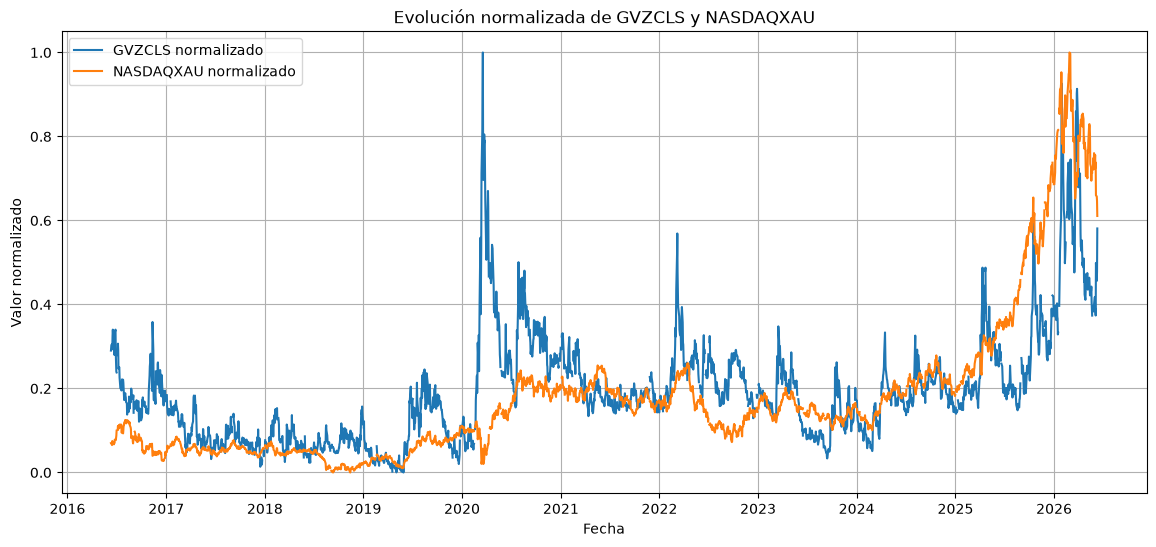

In [11]:
df_plot= df.set_index("Fecha")[["GVZCLS", "NASDAQXAU"]]

df_plot_norm= (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min())

plt.figure(figsize=(14, 6))
plt.plot(df_plot_norm.index, df_plot_norm["GVZCLS"], label="GVZCLS normalizado")
plt.plot(df_plot_norm.index, df_plot_norm["NASDAQXAU"], label="NASDAQXAU normalizado")
plt.title("Evolución normalizada de GVZCLS y NASDAQXAU")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado")
plt.legend()
plt.grid(True)
plt.show()

## ¿Cómo se distribuyen las variables principales?

Se analizan las distribuciones de `GVZCLS`, `NASDAQXAU` y sus retornos diarios.

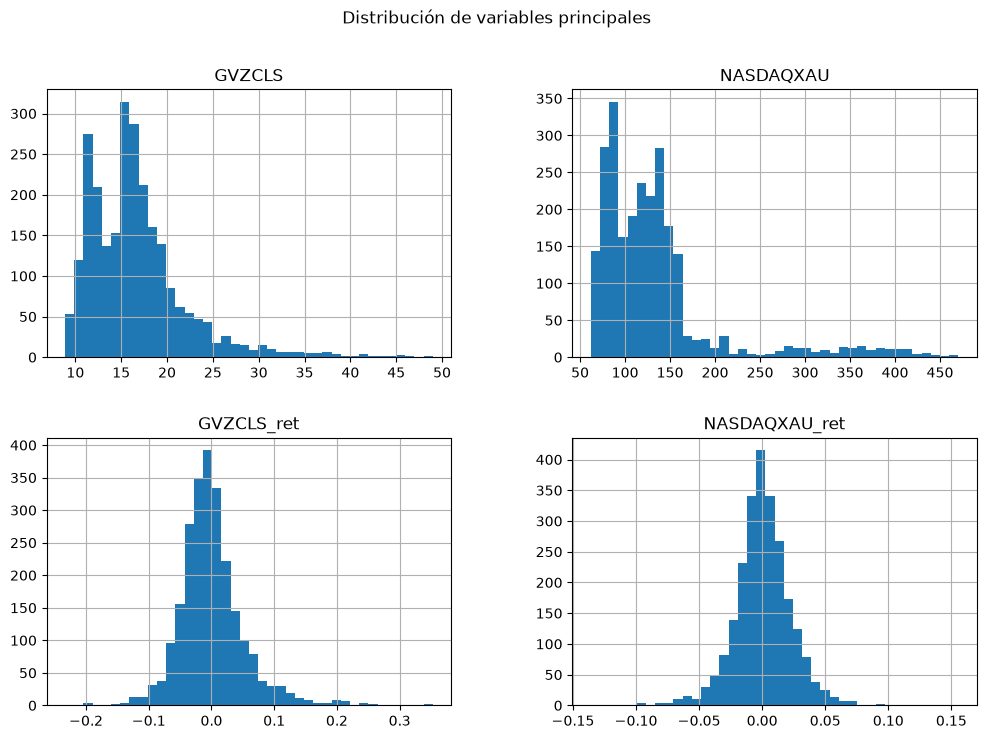

In [12]:
variables_distribucion= ["GVZCLS", "NASDAQXAU", "GVZCLS_ret", "NASDAQXAU_ret"]

df[variables_distribucion].hist(figsize=(12, 8), bins=40)
plt.suptitle("Distribución de variables principales")
plt.show()

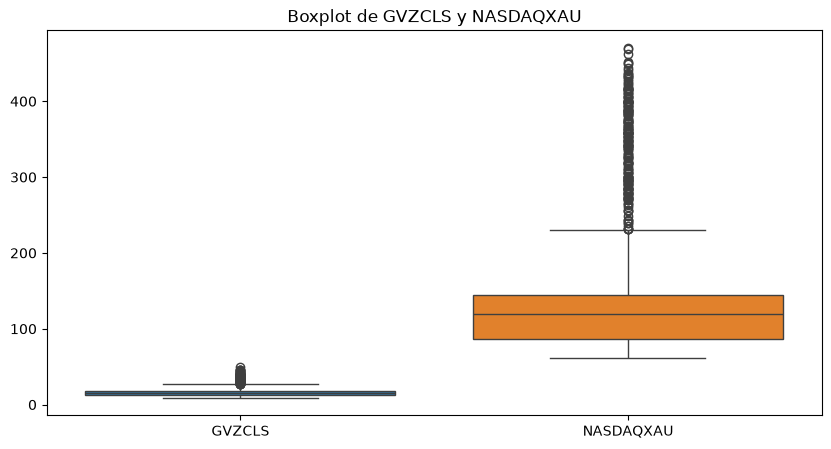

In [57]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["GVZCLS", "NASDAQXAU"]])
plt.title("Boxplot de GVZCLS y NASDAQXAU")
plt.show()

## ¿Existen datos faltantes en el dataset?

Se utiliza la librería `missingno` para visualizar los valores faltantes del dataset.

In [20]:
missing_counts= df.isna().sum().sort_values(ascending=False)
print(missing_counts)

XAU_sube_manana          191
NASDAQXAU_ret            191
XAU_sube_manana_cat      191
GVZCLS_ret               187
NASDAQXAU_manana          96
NASDAQXAU_lag1            96
NASDAQXAU                 95
GVZCLS_lag1               94
GVZCLS                    93
Rango_Volatilidad_Oro     93
NASDAQXAU_MA20             9
GVZCLS_MA20                9
NASDAQXAU_vol_5d           3
GVZCLS_vol_5d              3
NASDAQXAU_MA5              2
GVZCLS_MA5                 2
Año                        0
Fecha                      0
Trimestre                  0
Mes_num                    0
Dia_semana                 0
Mes                        0
dtype: int64


<Figure size 1200x600 with 0 Axes>

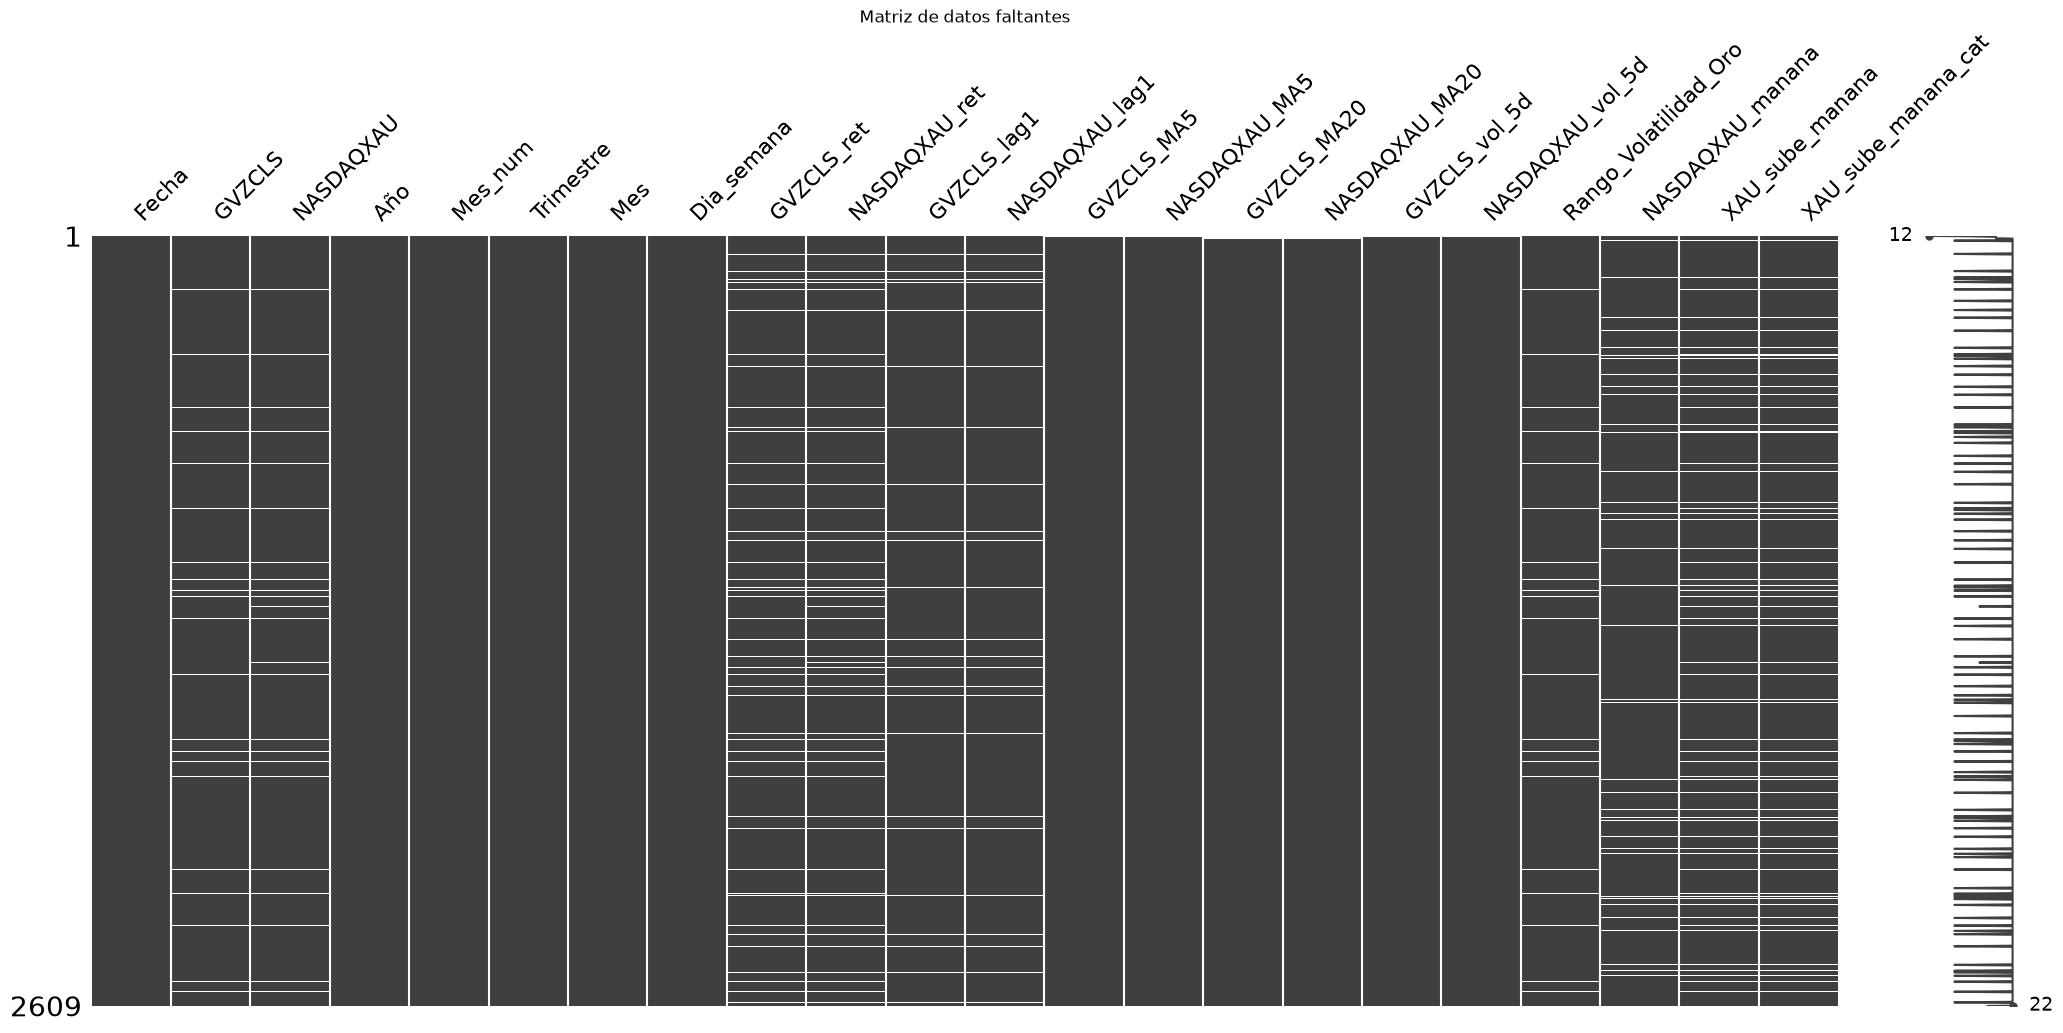

In [19]:
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title("Matriz de datos faltantes")
plt.show()

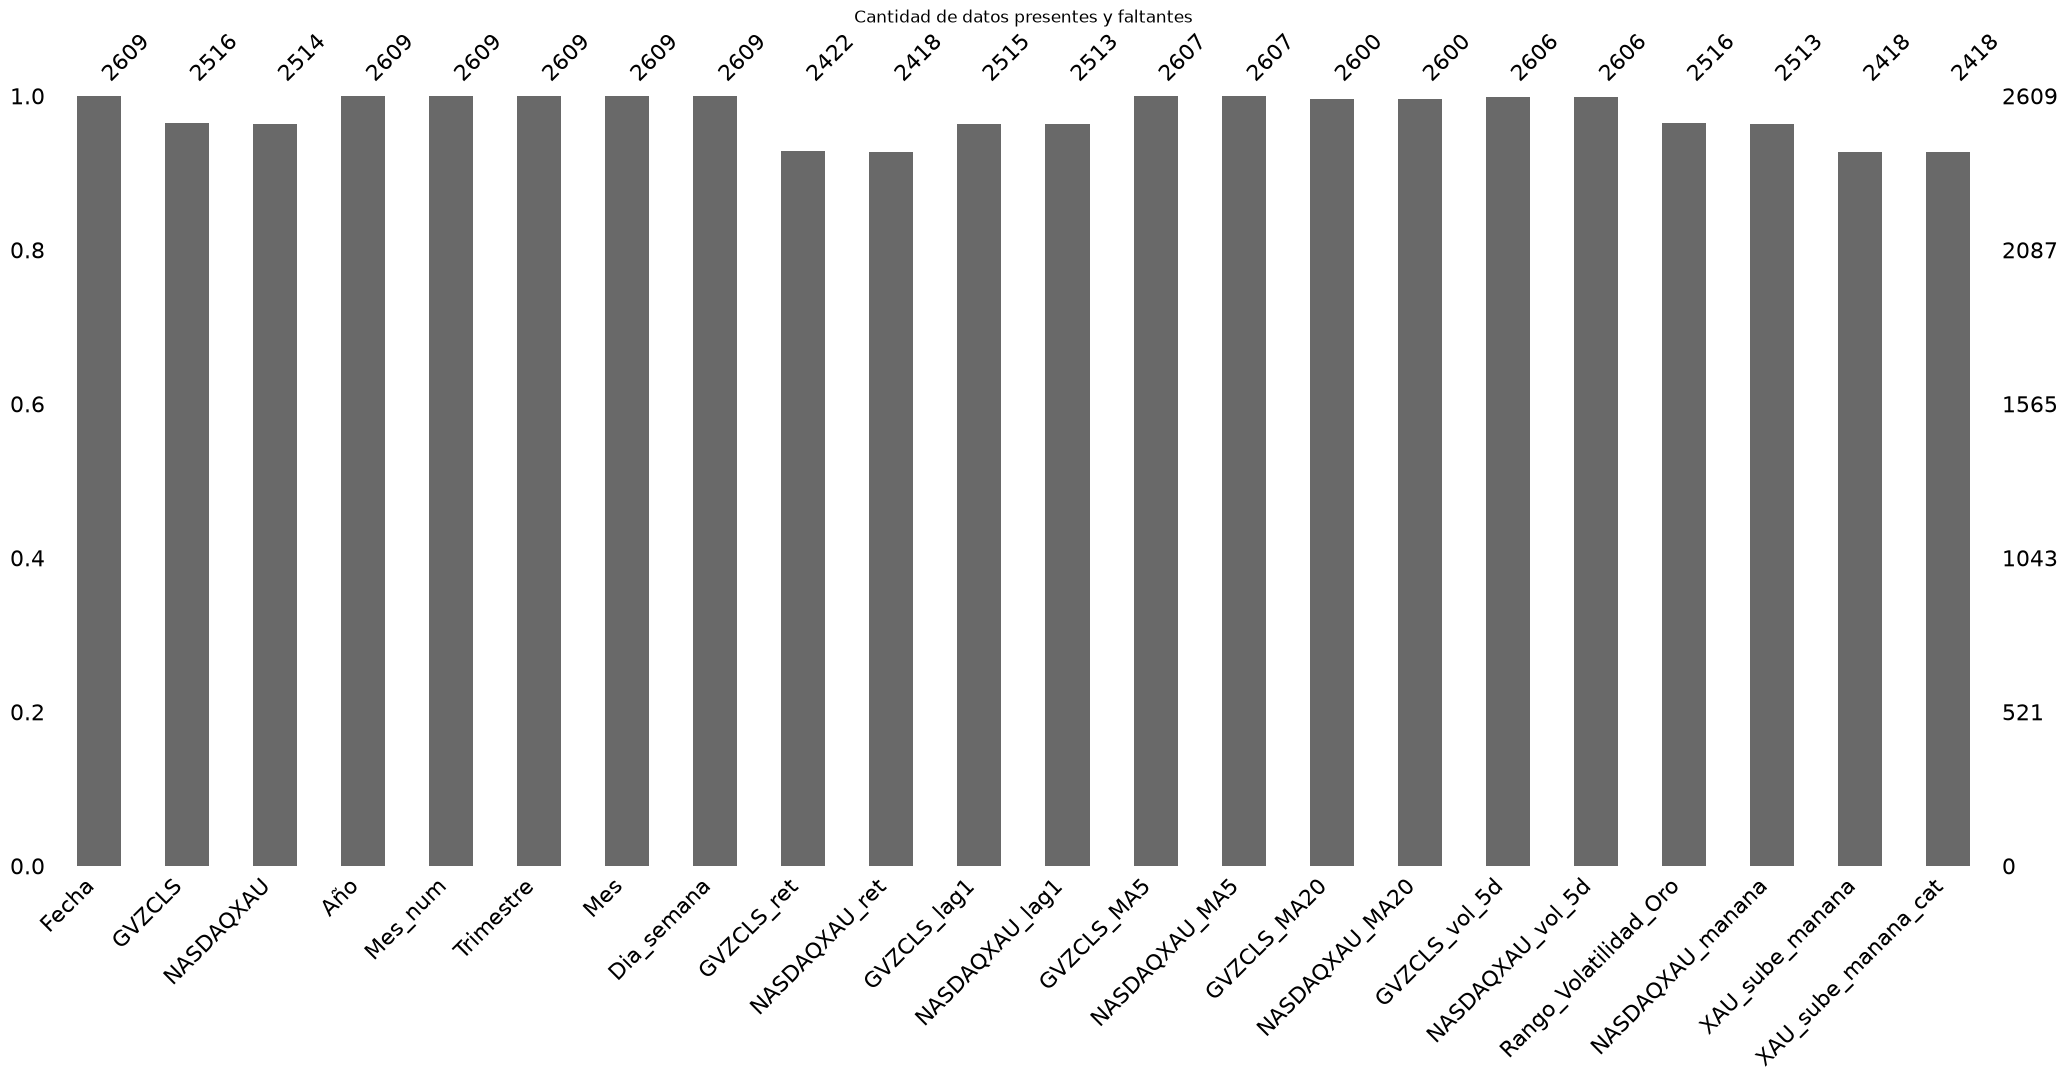

In [21]:
plt.figure(figsize=(12, 6))
msno.bar(df)
plt.title("Cantidad de datos presentes y faltantes")
plt.show()

## ¿Qué combinaciones de variables tienen datos faltantes?

,Combinación de variables con datos faltantes,Cantidad de filas
0,Sin datos faltantes,2314
1,NASDAQXAU_manana + XAU_sube_manana + XAU_sube_...,96
2,GVZCLS + NASDAQXAU + GVZCLS_ret + NASDAQXAU_re...,93
3,GVZCLS_ret + NASDAQXAU_ret + GVZCLS_lag1 + NAS...,93
4,GVZCLS_MA20 + NASDAQXAU_MA20,6
5,NASDAQXAU + NASDAQXAU_ret + XAU_sube_manana + ...,2
6,NASDAQXAU_ret + NASDAQXAU_lag1,2
7,GVZCLS_ret + NASDAQXAU_ret + GVZCLS_lag1 + NAS...,1
8,GVZCLS_MA5 + NASDAQXAU_MA5 + GVZCLS_MA20 + NAS...,1
9,GVZCLS_MA20 + NASDAQXAU_MA20 + GVZCLS_vol_5d +...,1


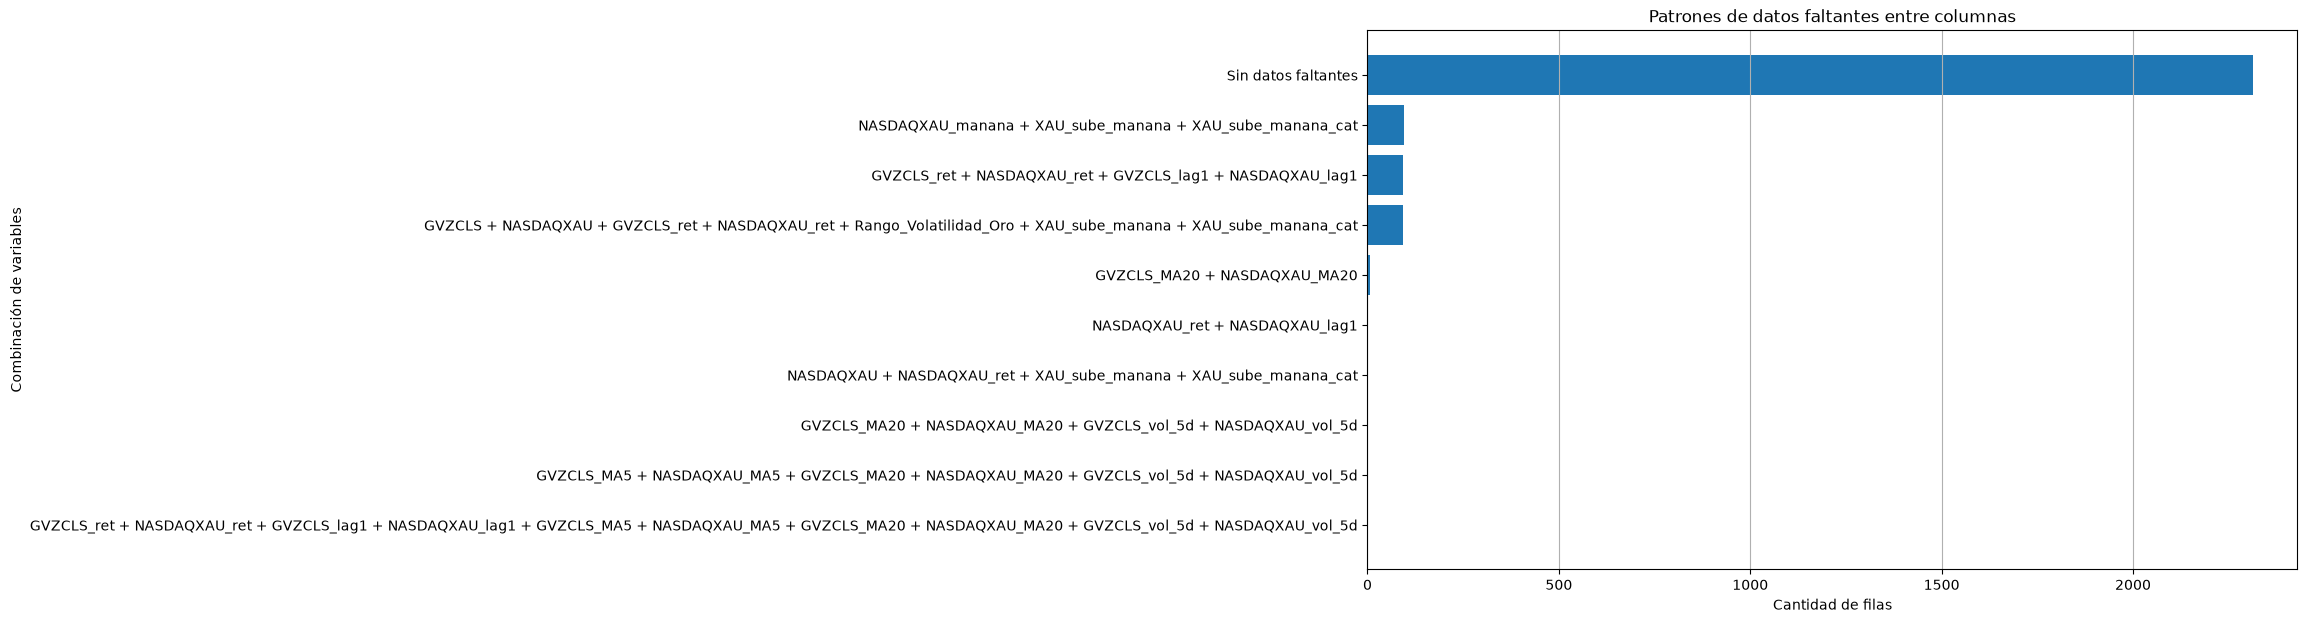

In [30]:
df= df.replace([np.inf, -np.inf], np.nan)
cols_missing= df.columns[df.isna().sum() > 0].tolist()

if len(cols_missing) == 0:
    print("No hay datos faltantes en el dataset.")
else:
    missing_bool = df[cols_missing].isna().astype(int)

    def crear_patron(row):
        columnas_faltantes = row.index[row == 1].tolist()
        if len(columnas_faltantes) == 0:
            return "Sin datos faltantes"
        return " + ".join(columnas_faltantes)

    missing_bool["Patron_faltante"]= missing_bool.apply(crear_patron, axis=1)

    patrones= (
        missing_bool["Patron_faltante"]
        .value_counts()
        .reset_index()
    )

    patrones.columns= ["Combinación de variables con datos faltantes", "Cantidad de filas"]

    display(patrones)

    patrones_top= patrones.head(15).sort_values("Cantidad de filas")
    plt.figure(figsize=(12, 7))
    plt.barh(
        patrones_top["Combinación de variables con datos faltantes"],
        patrones_top["Cantidad de filas"]
    )
    plt.title("Patrones de datos faltantes entre columnas")
    plt.xlabel("Cantidad de filas")
    plt.ylabel("Combinación de variables")
    plt.grid(axis="x")
    plt.show()

## ¿Qué se hará con los valores faltantes?

Primero se revisan las columnas con más de 250 valores faltantes.
Si existen, se eliminan. Luego se imputan los valores faltantes restantes:
- Variables numéricas: mediana.
- Variables categóricas: moda.

In [31]:
missing_counts= df.isna().sum().sort_values(ascending=False)
cols_to_drop= missing_counts[missing_counts > 250].index.tolist()
print("Columnas con más de 250 valores faltantes:")
print(cols_to_drop)

Columnas con más de 250 valores faltantes:
[]


In [33]:
df_clean= df.drop(columns=cols_to_drop)
target_cols= [
    "XAU_sube_manana",
    "XAU_sube_manana_cat",
    "NASDAQXAU_manana"
]

feature_cols= [
    col for col in df_clean.columns
    if col not in target_cols + ["Fecha"]
]

num_features= [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(df_clean[col])
]

cat_features= [
    col for col in feature_cols
    if col not in num_features
]

df_imputed= df_clean.copy()

num_imputer= SimpleImputer(strategy="median")
cat_imputer= SimpleImputer(strategy="most_frequent")

df_imputed[num_features]= num_imputer.fit_transform(df_imputed[num_features])
df_imputed[cat_features]= cat_imputer.fit_transform(df_imputed[cat_features])

print("Valores faltantes después de la imputación:")
print(df_imputed[feature_cols].isna().sum().sort_values(ascending=False))

Valores faltantes después de la imputación:
GVZCLS                   0
NASDAQXAU                0
Año                      0
Mes_num                  0
Trimestre                0
Mes                      0
Dia_semana               0
GVZCLS_ret               0
NASDAQXAU_ret            0
GVZCLS_lag1              0
NASDAQXAU_lag1           0
GVZCLS_MA5               0
NASDAQXAU_MA5            0
GVZCLS_MA20              0
NASDAQXAU_MA20           0
GVZCLS_vol_5d            0
NASDAQXAU_vol_5d         0
Rango_Volatilidad_Oro    0
dtype: int64


## ¿La categoría de volatilidad del oro se relaciona con la dirección del índice NASDAQXAU?

Se agrupan los días según el nivel de volatilidad del oro: baja, media o alta; luego se compara cuántas veces el índice NASDAQXAU sube o baja al día siguiente.

In [34]:
tabla_categoria= pd.crosstab(
    df["Rango_Volatilidad_Oro"],
    df["XAU_sube_manana_cat"]
)
display(tabla_categoria)

XAU_sube_manana_cat,Baja o igual,Sube
Rango_Volatilidad_Oro,,
Baja,413,395
Media,395,405
Alta,395,415


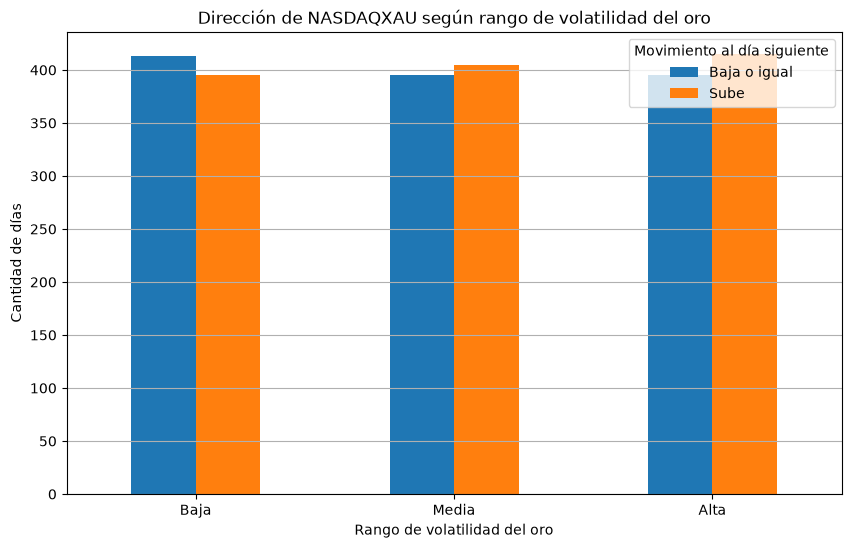

In [35]:
tabla_categoria.plot(kind="bar", figsize=(10, 6))
plt.title("Dirección de NASDAQXAU según rango de volatilidad del oro")
plt.xlabel("Rango de volatilidad del oro")
plt.ylabel("Cantidad de días")
plt.xticks(rotation=0)
plt.legend(title="Movimiento al día siguiente")
plt.grid(axis="y")
plt.show()

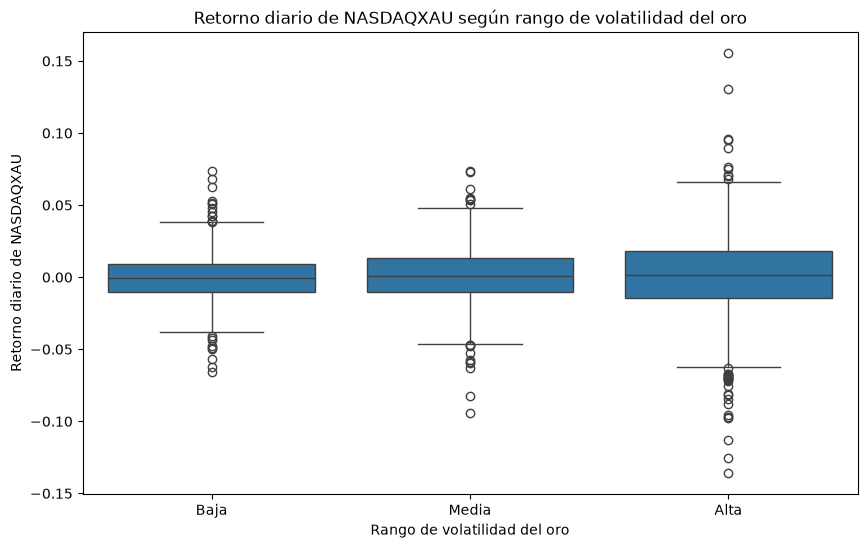

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="Rango_Volatilidad_Oro",
    y="NASDAQXAU_ret"
)
plt.title("Retorno diario de NASDAQXAU según rango de volatilidad del oro")
plt.xlabel("Rango de volatilidad del oro")
plt.ylabel("Retorno diario de NASDAQXAU")
plt.show()

## ¿Existe correlación lineal entre la volatilidad del oro y el índice NASDAQXAU?

Se calcula la correlación de Pearson entre las variables numéricas.
Este análisis permite observar relaciones lineales entre variables.

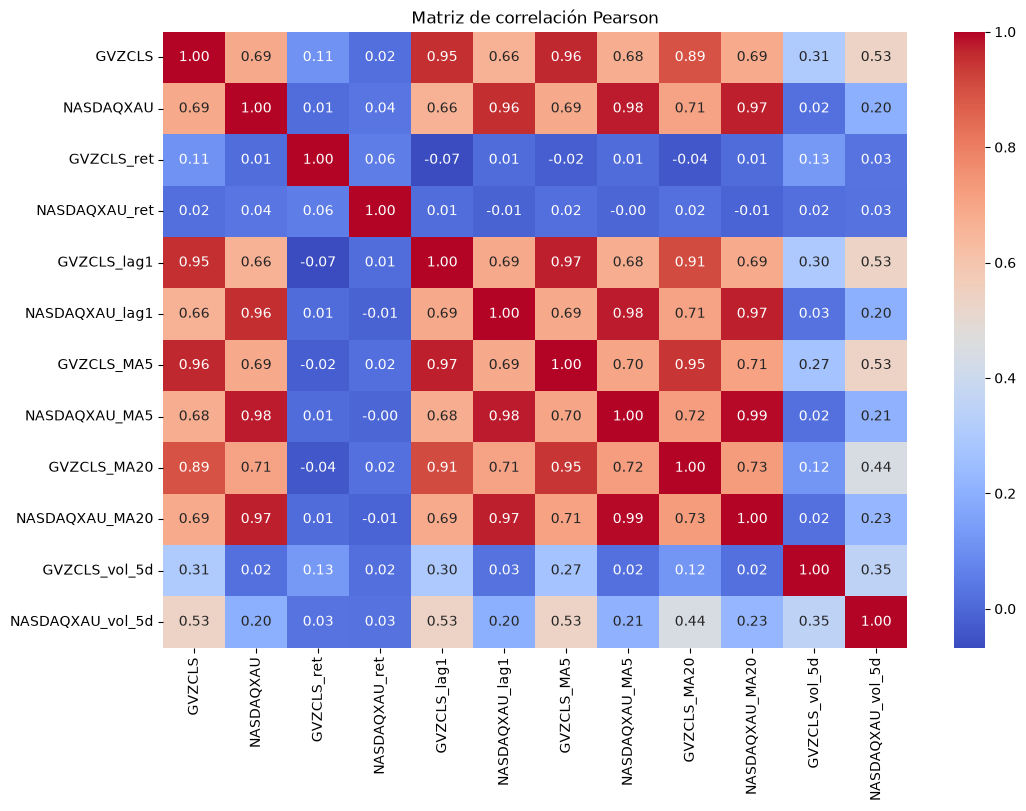

In [37]:
corr_cols= [
    "GVZCLS",
    "NASDAQXAU",
    "GVZCLS_ret",
    "NASDAQXAU_ret",
    "GVZCLS_lag1",
    "NASDAQXAU_lag1",
    "GVZCLS_MA5",
    "NASDAQXAU_MA5",
    "GVZCLS_MA20",
    "NASDAQXAU_MA20",
    "GVZCLS_vol_5d",
    "NASDAQXAU_vol_5d"
]

pearson_corr= df_imputed[corr_cols].corr(method="pearson")
plt.figure(figsize=(12, 8))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación Pearson")
plt.show()

In [38]:
print("Correlación Pearson entre GVZCLS y NASDAQXAU:")
print(pearson_corr.loc["GVZCLS", "NASDAQXAU"])
print("\nCorrelación Pearson entre retornos de GVZCLS y NASDAQXAU:")
print(pearson_corr.loc["GVZCLS_ret", "NASDAQXAU_ret"])

Correlación Pearson entre GVZCLS y NASDAQXAU:
0.6903189969065499

Correlación Pearson entre retornos de GVZCLS y NASDAQXAU:
0.05655792296987016


## ¿Existe relación monotónica entre las variables?

Se calcula la correlación de Spearman.

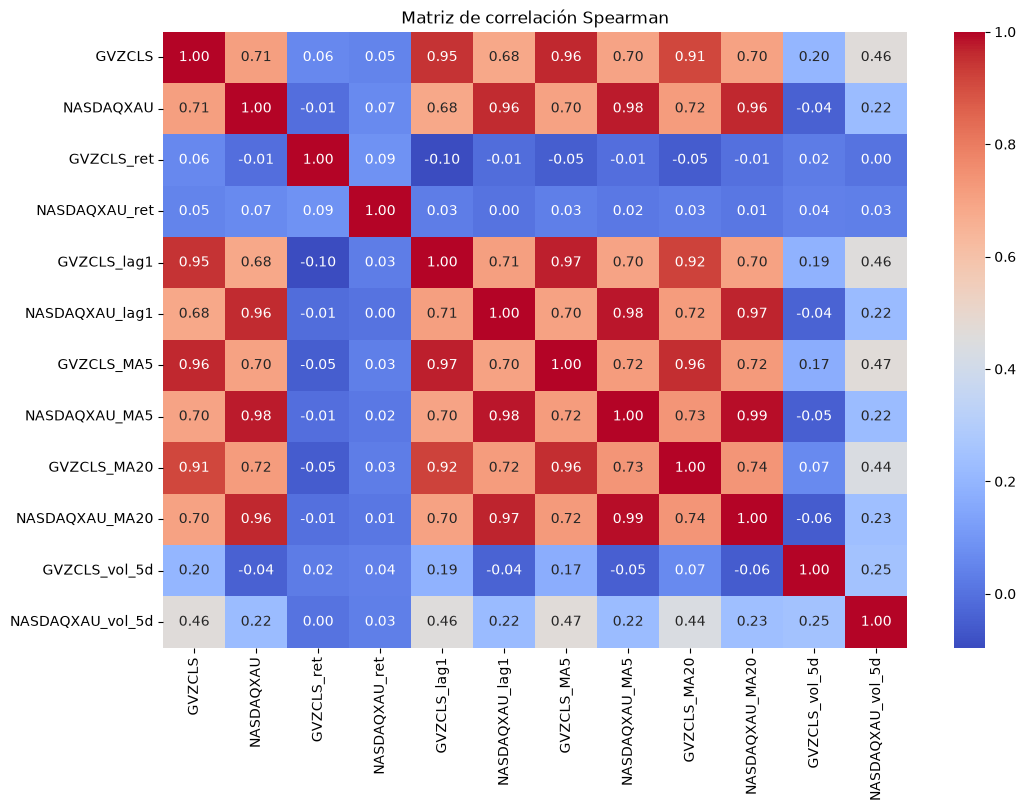

In [39]:
spearman_corr= df_imputed[corr_cols].corr(method="spearman")
plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación Spearman")
plt.show()

In [40]:
print("Correlación Spearman entre GVZCLS y NASDAQXAU:")
print(spearman_corr.loc["GVZCLS", "NASDAQXAU"])
print("\nCorrelación Spearman entre retornos de GVZCLS y NASDAQXAU:")
print(spearman_corr.loc["GVZCLS_ret", "NASDAQXAU_ret"])

Correlación Spearman entre GVZCLS y NASDAQXAU:
0.7093403726825129

Correlación Spearman entre retornos de GVZCLS y NASDAQXAU:
0.0878191096936693


Observación: El análisis de correlación permite evaluar si la volatilidad del oro se mueve de manera relacionada con el índice del sector oro/plata. La correlación entre los niveles de GVZCLS y NASDAQXAU puede ser moderada, pero la correlación entre retornos diarios suele ser menor. Esto indica que, aunque ambas series pueden tener cierta relación general, predecir movimientos diarios del sector oro/plata únicamente con la volatilidad del oro puede ser difícil.

## ¿Qué variables se usarán para entrenar los modelos?

Para clasificación, la variable objetivo será:
`XAU_sube_manana`

Donde:
- 1 = NASDAQXAU sube al día siguiente.
- 0 = NASDAQXAU baja o se mantiene igual al día siguiente.

Para regresión, la variable objetivo será:
`NASDAQXAU_manana`
Que representa el valor continuo del índice NASDAQXAU al día siguiente.

In [41]:
feature_cols= [
    col for col in df_imputed.columns
    if col not in [
        "Fecha",
        "XAU_sube_manana",
        "XAU_sube_manana_cat",
        "NASDAQXAU_manana"
    ]
]

print("Variables predictoras:")
print(feature_cols)

Variables predictoras:
['GVZCLS', 'NASDAQXAU', 'Año', 'Mes_num', 'Trimestre', 'Mes', 'Dia_semana', 'GVZCLS_ret', 'NASDAQXAU_ret', 'GVZCLS_lag1', 'NASDAQXAU_lag1', 'GVZCLS_MA5', 'NASDAQXAU_MA5', 'GVZCLS_MA20', 'NASDAQXAU_MA20', 'GVZCLS_vol_5d', 'NASDAQXAU_vol_5d', 'Rango_Volatilidad_Oro']


In [42]:
def make_preprocessor(X):
    numeric= X.select_dtypes(include=np.number).columns.tolist()
    categorical= X.select_dtypes(exclude=np.number).columns.tolist()

    try:
        encoder= OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder= OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocessor= ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric),
            ("cat", encoder, categorical)
        ]
    )
    return preprocessor

## ¿Puede un modelo KNN predecir si NASDAQXAU sube al día siguiente?

Se entrena un modelo KNN para clasificar si el índice NASDAQXAU subirá o no al día siguiente.

In [43]:
classification_data= df_imputed.dropna(subset=["XAU_sube_manana"]).copy()

X_clf= classification_data[feature_cols]
y_clf= classification_data["XAU_sube_manana"].astype(int)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

knn_model= Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(X_clf)),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_model.fit(X_train_clf, y_train_clf)

knn_train_pred= knn_model.predict(X_train_clf)
knn_test_pred= knn_model.predict(X_test_clf)

knn_train_acc= accuracy_score(y_train_clf, knn_train_pred)
knn_test_acc= accuracy_score(y_test_clf, knn_test_pred)

print("Accuracy entrenamiento KNN:", knn_train_acc)
print("Accuracy prueba KNN:", knn_test_acc)
print("\nReporte de clasificación KNN:")
print(classification_report(y_test_clf, knn_test_pred))

Accuracy entrenamiento KNN: 0.6825232678386763
Accuracy prueba KNN: 0.5206611570247934

Reporte de clasificación KNN:
              precision    recall  f1-score   support

           0       0.52      0.54      0.53       241
           1       0.52      0.51      0.51       243

    accuracy                           0.52       484
   macro avg       0.52      0.52      0.52       484
weighted avg       0.52      0.52      0.52       484



## ¿Puede un modelo Random Forest predecir si NASDAQXAU sube al día siguiente?

Se entrena un segundo modelo de clasificación usando Random Forest para comparar su rendimiento con KNN.

In [44]:
rf_clf_model= Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(X_clf)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_clf_model.fit(X_train_clf, y_train_clf)

rf_train_pred= rf_clf_model.predict(X_train_clf)
rf_test_pred= rf_clf_model.predict(X_test_clf)

rf_train_acc= accuracy_score(y_train_clf, rf_train_pred)
rf_test_acc= accuracy_score(y_test_clf, rf_test_pred)

print("Accuracy entrenamiento Random Forest:", rf_train_acc)
print("Accuracy prueba Random Forest:", rf_test_acc)

print("\nReporte de clasificación Random Forest:")
print(classification_report(y_test_clf, rf_test_pred))

Accuracy entrenamiento Random Forest: 1.0
Accuracy prueba Random Forest: 0.506198347107438

Reporte de clasificación Random Forest:
              precision    recall  f1-score   support

           0       0.50      0.55      0.52       241
           1       0.51      0.47      0.49       243

    accuracy                           0.51       484
   macro avg       0.51      0.51      0.51       484
weighted avg       0.51      0.51      0.51       484



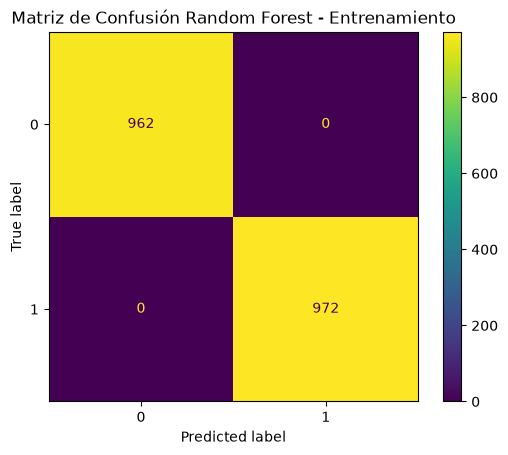

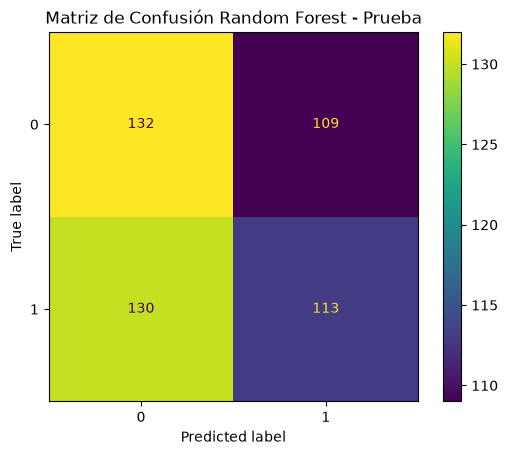

In [45]:
ConfusionMatrixDisplay.from_predictions(y_train_clf, rf_train_pred)
plt.title("Matriz de Confusión Random Forest - Entrenamiento")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test_clf, rf_test_pred)
plt.title("Matriz de Confusión Random Forest - Prueba")
plt.show()

In [48]:
classification_results= pd.DataFrame({
    "Modelo": ["KNN", "Random Forest"],
    "Accuracy entrenamiento": [knn_train_acc, rf_train_acc],
    "Accuracy prueba": [knn_test_acc, rf_test_acc]
})

display(classification_results)

,Modelo,Accuracy entrenamiento,Accuracy prueba
0,KNN,0.682523,0.520661
1,Random Forest,1.000000,0.506198


Se entrenaron dos modelos de clasificación: KNN y Random Forest. La variable objetivo fue `XAU_sube_manana`, que indica si el índice NASDAQXAU sube o no al día siguiente.

El accuracy en prueba permite evaluar qué tan bien generaliza cada modelo. Si el accuracy se mantiene cerca de 0.50, significa que el modelo tiene dificultad para predecir la dirección diaria del mercado, lo cual es común en datos financieros. Si el accuracy de entrenamiento es muy alto pero el de prueba es bajo, puede existir sobreajuste.

## ¿Puede un modelo SVR predecir el valor de NASDAQXAU al día siguiente?

Se utiliza un modelo de regresión SVR para predecir la variable continua `NASDAQXAU_manana`.

In [49]:
regression_data= df_imputed.dropna(subset=["NASDAQXAU_manana"]).copy()

X_reg= regression_data[feature_cols]
y_reg= regression_data["NASDAQXAU_manana"].astype(float)

X_train_reg, X_test_reg, y_train_reg, y_test_reg= train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

svr_model= Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(X_reg)),
        ("model", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))
    ]
)

svr_model.fit(X_train_reg, y_train_reg)

svr_train_pred= svr_model.predict(X_train_reg)
svr_test_pred= svr_model.predict(X_test_reg)

svr_train_r2= r2_score(y_train_reg, svr_train_pred)
svr_test_r2= r2_score(y_test_reg, svr_test_pred)

print("R² entrenamiento SVR:", svr_train_r2)
print("R² prueba SVR:", svr_test_r2)

print("MAE prueba SVR:", mean_absolute_error(y_test_reg, svr_test_pred))
print("RMSE prueba SVR:", np.sqrt(mean_squared_error(y_test_reg, svr_test_pred)))

R² entrenamiento SVR: 0.9977878113737655
R² prueba SVR: 0.9811943042949143
MAE prueba SVR: 3.9413275267466243
RMSE prueba SVR: 9.258975984811759


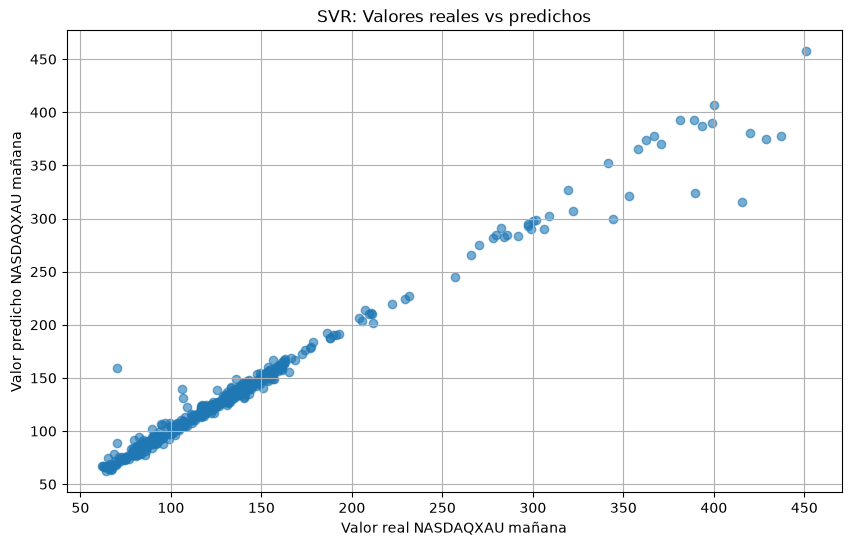

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, svr_test_pred, alpha=0.6)
plt.xlabel("Valor real NASDAQXAU mañana")
plt.ylabel("Valor predicho NASDAQXAU mañana")
plt.title("SVR: Valores reales vs predichos")
plt.grid(True)
plt.show()

## ¿Puede un modelo Random Forest Regressor predecir el valor de NASDAQXAU al día siguiente?

Se entrena un segundo modelo de regresión usando Random Forest Regressor para comparar su rendimiento con SVR.

In [51]:
rf_reg_model= Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(X_reg)),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_reg_model.fit(X_train_reg, y_train_reg)

rf_reg_train_pred= rf_reg_model.predict(X_train_reg)
rf_reg_test_pred= rf_reg_model.predict(X_test_reg)

rf_reg_train_r2= r2_score(y_train_reg, rf_reg_train_pred)
rf_reg_test_r2= r2_score(y_test_reg, rf_reg_test_pred)

print("R² entrenamiento Random Forest Regressor:", rf_reg_train_r2)
print("R² prueba Random Forest Regressor:", rf_reg_test_r2)

print("MAE prueba Random Forest Regressor:", mean_absolute_error(y_test_reg, rf_reg_test_pred))
print("RMSE prueba Random Forest Regressor:", np.sqrt(mean_squared_error(y_test_reg, rf_reg_test_pred)))

R² entrenamiento Random Forest Regressor: 0.9993878186527791
R² prueba Random Forest Regressor: 0.9958701447797141
MAE prueba Random Forest Regressor: 2.530641848906558
RMSE prueba Random Forest Regressor: 4.338960223736322


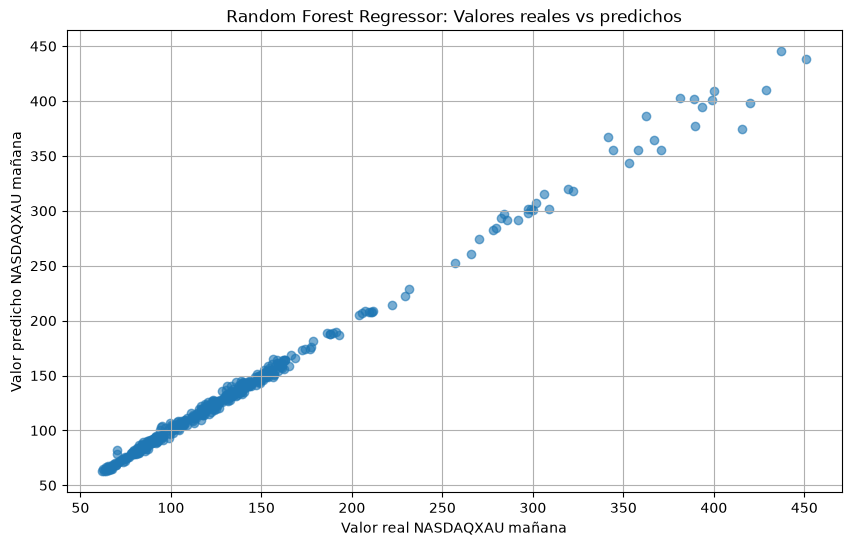

In [52]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, rf_reg_test_pred, alpha=0.6)
plt.xlabel("Valor real NASDAQXAU mañana")
plt.ylabel("Valor predicho NASDAQXAU mañana")
plt.title("Random Forest Regressor: Valores reales vs predichos")
plt.grid(True)
plt.show()

In [53]:
regression_results= pd.DataFrame({
    "Modelo": ["SVR", "Random Forest Regressor"],
    "R² entrenamiento": [svr_train_r2, rf_reg_train_r2],
    "R² prueba": [svr_test_r2, rf_reg_test_r2],
    "MAE prueba": [
        mean_absolute_error(y_test_reg, svr_test_pred),
        mean_absolute_error(y_test_reg, rf_reg_test_pred)
    ],
    "RMSE prueba": [
        np.sqrt(mean_squared_error(y_test_reg, svr_test_pred)),
        np.sqrt(mean_squared_error(y_test_reg, rf_reg_test_pred))
    ]
})

display(regression_results)

,Modelo,R² entrenamiento,R² prueba,MAE prueba,RMSE prueba
0,SVR,0.997788,0.981194,3.941328,9.258976
1,Random Forest Regressor,0.999388,0.995870,2.530642,4.338960


Se entrenaron dos modelos de regresión: SVR y Random Forest Regressor. La variable objetivo fue `NASDAQXAU_manana`, que representa el valor del índice NASDAQXAU al día siguiente.

El coeficiente R² permite medir qué tan bien el modelo explica la variabilidad de la variable objetivo. Un R² cercano a 1 indica buen ajuste, mientras que un R² cercano a 0 indica bajo poder predictivo.

En este caso, es posible obtener mejores resultados en regresión que en clasificación porque el valor actual de NASDAQXAU suele estar fuertemente relacionado con su valor del día siguiente.

## ¿Qué modelo tuvo mejor desempeño?

Se comparan los resultados de clasificación y regresión para determinar qué modelos funcionaron mejor.

In [54]:
display(classification_results)
display(regression_results)

,Modelo,Accuracy entrenamiento,Accuracy prueba
0,KNN,0.682523,0.520661
1,Random Forest,1.000000,0.506198


,Modelo,R² entrenamiento,R² prueba,MAE prueba,RMSE prueba
0,SVR,0.997788,0.981194,3.941328,9.258976
1,Random Forest Regressor,0.999388,0.995870,2.530642,4.338960


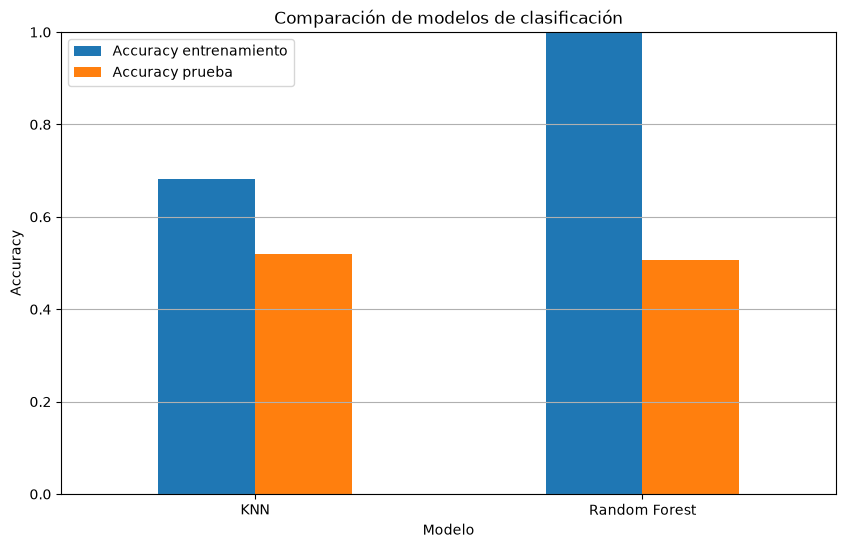

In [55]:
classification_results.plot(
    x="Modelo",
    y=["Accuracy entrenamiento", "Accuracy prueba"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparación de modelos de clasificación")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## ¿Qué archivos se pueden usar para construir el dashboard?

Se exportan tres archivos:

1. Dataset limpio e imputado.
2. Resultados de clasificación.
3. Resultados de regresión.

Estos archivos pueden usarse en Power BI, Tableau, Excel o Looker Studio.

In [56]:
df_imputed.to_csv("gold_dataset_limpio.csv", index=False)
classification_results.to_csv("resultados_clasificacion.csv", index=False)
regression_results.to_csv("resultados_regresion.csv", index=False)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.
